# import and config

In [1]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from matplotlib.lines import Line2D


# =============================================================================
# Global options
# =============================================================================

# BASE_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/ablation_last")
BASE_RESULTS_DIR = Path("/Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_022933_ablation")


# Choose among:
# "dataset", "kernel_method", "model_type", "max_depth", "min_samples_leaf"

ABLATION_MODE_TO_PLOT = [
    # 'dataset',
    'kernel_method',
    'model_type',
                        
                        'min_samples_leaf',
                         'max_depth', 
                         ]

# For ABLATION_MODE != "dataset", produce one figure per dataset for these datasets
SELECTED_DATASETS = [
    "airlines",

    # "celegans",

    "covertype",
    "epsilon",
    "higgs",
    "pathmnist_28",
    "pbmc",
    "susy",
    "tissuemnist_28",
    "tv_news_combined",
]

# For non-dataset ablations, you may want to restrict to a smaller set, e.g.:
SELECTED_DATASETS_OTHER_ABLATIONS = [
    'airlines',
    'covertype'
    # "tv_news_combined",
    # "pbmc",
]

# Optional explicit order of ablation levels for non-dataset modes.
# Use None to keep discovered order.
SELECTED_ABLATION_LEVELS = None

# Number of dataset blocks per row for non-dataset ablations
OTHER_ABLATION_DATASET_BLOCKS_PER_ROW = 2

# Width scaling for multi-dataset figures
OTHER_ABLATION_FIG_WIDTH_SCALE = 2.0

# Vertical gap from dataset title to legend, in figure coordinates
OTHER_ABLATION_DATASET_TITLE_GAP = 0.02


# Keep only points with n_train_subset >= 2**MIN_POW
MIN_POW = 14

# Use the same number of columns for the top legend and the m=... layout
N_COL_LEG = 4          # top legend
N_COL_SLOPE_LEG = 2    # m=... legends inside each subplot


# Spacing between top legend and top of subplots
LEG_SPACE_TOP = 0.07  # decrease if legend is too far from subplots, increase if it's too close

# Error band options
PLOT_ERROR_BANDS = True
BAND_TYPE = "std"   # "se" or "std"

# Line / marker style options
LINE_THICKNESS_DATASET = 0.5
MARKER_SIZE_DATASET = 2
DISTINCT_MARKERS_DATASET = True

LINE_THICKNESS_OTHER = 0.5
MARKER_SIZE_OTHER = 2
DISTINCT_MARKERS_OTHER = True

# Slope text options
SHOW_SLOPE_TEXT = True
N_TAIL = 4

# Vertical spacing between stacked rows of subplots
STACKED_ROW_HSPACE = 0.22

# Spacing between stacked rows legend
STACKED_ROW_LEGEND_GAP = 0.00  # for stacked row legends only

TOP_ROW_LEGEND_GAP = 0.012

# SIAM single-column width
COLUMN_WIDTH_PT = 241.0
PT_TO_IN = 1.0 / 72.27
FIG_WIDTH = COLUMN_WIDTH_PT * PT_TO_IN
FIG_HEIGHT_TWO_PANEL = 4.6

# Output directory
FIG_DIR = Path("./compiled_ablation_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 7.5,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})


# =============================================================================
# Display names
# =============================================================================

DATASET_DISPLAY_NAMES = {
    "higgs": "Higgs",
    "susy": "SUSY",
    "airlines": "Airlines",
    "celegans": "CElegans",
    "covertype": "Covertype",
    "epsilon": "Epsilon",
    "nsl_kdd+": "NSL-KDD+",
    "pathmnist_28": "PathMNIST",
    "pbmc": "PBMC",
    "sign_mnist": "SignMNIST",
    "tissuemnist_28": "TissueMNIST",
    "tv_news_combined": "TV News",
    "zilionis": "Zilionis",
}

ABLATION_MODE_TO_FOLDER = {
    "dataset": "dataset",
    "kernel_method": "kernel_method",
    "model_type": "model_type",
    "max_depth": "max_depth",
    "min_samples_leaf": "min_samples_leaf",
}

ABLATION_MODE_TO_FILENAME = {
    "dataset": "dataset_results.csv",
    "kernel_method": "kernel_method_results.csv",
    "model_type": "model_type_results.csv",
    "max_depth": "max_depth_results.csv",
    "min_samples_leaf": "min_samples_leaf_results.csv",
}



# plot


Loading CSV for kernel_method: /Users/aumona/Projects/RF-GAP-Python/experiments/results/20260413_022933_ablation/kernel_method/kernel_method_results.csv
ABLATION_MODE: kernel_method
Rows after filtering/truncation: 240
Datasets to plot: ['airlines', 'covertype']
Plot error bands: True
Band type: std
Show slope text: True
N_TAIL: 4
N_COL_LEG: 4

Dataset: airlines
Ablation levels: ['original', 'kerf', 'oob', 'gap']
  original: [np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(485444)]
  kerf: [np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(485444)]
  oob: [np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(485444)]
  gap: [np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(485444)]

Dataset: covertype
Ablation levels: ['original', 'kerf', 'oob', 'gap']
  original: [np.int64(16384), np.int64(32768), np.in

/var/folders/4d/gg_x7bzj2kx7ln44mdwqlw480000gn/T/ipykernel_88978/3266200809.py:271: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  values = list(pd.unique(values))
/var/folders/4d/gg_x7bzj2kx7ln44mdwqlw480000gn/T/ipykernel_88978/3266200809.py:271: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  values = list(pd.unique(values))
/var/folders/4d/gg_x7bzj2kx7ln44mdwqlw480000gn/T/ipykernel_88978/3266200809.py:271: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  values = list(pd.unique(values))
/var/folders/4d/gg_x7bzj2kx7ln44mdwqlw480000gn/T/ipykernel_88978/3266200809.py:271: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated

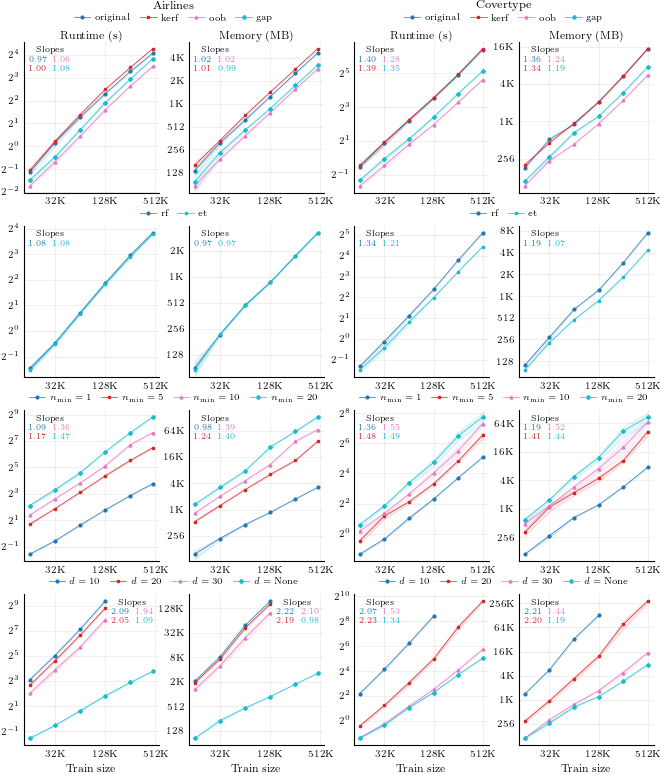

In [2]:
# =============================================================================
# Helpers
# =============================================================================

def dataset_plot_title(name: str) -> str:
    return DATASET_DISPLAY_NAMES.get(name, name)


def safe_parse_dict(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return {}


def get_results_csv_path(base_dir: Path, ablation_mode: str) -> Path:
    if ablation_mode not in ABLATION_MODE_TO_FOLDER:
        raise ValueError(f"Unknown ABLATION_MODE: {ablation_mode}")
    folder = ABLATION_MODE_TO_FOLDER[ablation_mode]
    filename = ABLATION_MODE_TO_FILENAME[ablation_mode]
    return base_dir / folder / filename


def extract_ablation_value(row, ablation_mode: str):
    if ablation_mode == "dataset":
        return row["dataset"]

    if ablation_mode == "kernel_method":
        return row["kernel_method"]

    if ablation_mode == "model_type":
        return row["model_type"]

    cfg = safe_parse_dict(row.get("ablation_cfg", None))

    if ablation_mode == "max_depth":
        val = cfg.get("max_depth", None)
        return "None" if val is None else str(val)

    if ablation_mode == "min_samples_leaf":
        val = cfg.get("min_samples_leaf", None)
        return "None" if val is None else str(val)

    raise ValueError(f"Unknown ABLATION_MODE: {ablation_mode}")


def get_style_settings(ablation_mode: str, n_groups: int):
    if ablation_mode == "dataset":
        line_thickness = LINE_THICKNESS_DATASET
        marker_size = MARKER_SIZE_DATASET
        use_distinct_markers = DISTINCT_MARKERS_DATASET
    else:
        line_thickness = LINE_THICKNESS_OTHER
        marker_size = MARKER_SIZE_OTHER
        use_distinct_markers = DISTINCT_MARKERS_OTHER

    marker_pool = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "8"]

    if use_distinct_markers:
        markers = [marker_pool[i % len(marker_pool)] for i in range(n_groups)]
    else:
        markers = ["o"] * n_groups

    return line_thickness, marker_size, markers


def add_slope_legend(
    ax,
    slope_items,
    ncol,
    fontsize=6.0,
    loc="best",
    title="Slopes",
):
    if len(slope_items) == 0:
        return None

    handles = [
        Line2D([], [], linestyle="none", linewidth=0, marker=None)
        for _ in slope_items
    ]
    labels = [text for _, text in slope_items]

    leg = ax.legend(
        handles,
        labels,
        loc=loc,
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        title=title,
        title_fontsize=fontsize,
        handlelength=0.0,
        handletextpad=0.0,
        columnspacing=0.8,
        labelspacing=0.2,
        borderaxespad=0.2,
    )

    for txt, (color, _) in zip(leg.get_texts(), slope_items):
        txt.set_color(color)

    return leg


def ablation_value_sort_key(val):
    if val == "None":
        return (1, float("inf"), str(val))
    try:
        return (0, float(val), str(val))
    except Exception:
        return (0, str(val), str(val))


def format_ablation_label(ablation_mode: str, val: str) -> str:
    if ablation_mode == "dataset":
        return dataset_plot_title(val)
    if ablation_mode == "kernel_method":
        return str(val)
    if ablation_mode == "model_type":
        return str(val)
    if ablation_mode == "max_depth":
        return rf"$d={val}$" if val != "None" else r"$d=\mathrm{None}$"
    if ablation_mode == "min_samples_leaf":
        return rf"$n_{{\min}}={val}$" if val != "None" else r"$n_{\min}=\mathrm{None}$"
    return str(val)


def summarize_curve(df: pd.DataFrame, y_col: str, group_col: str) -> pd.DataFrame:
    out = (
        df.groupby([group_col, "n_train_subset"], as_index=False)[y_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    out["sem"] = out["std"] / np.sqrt(out["count"])

    out["lower_se"] = out["mean"] - out["sem"]
    out["upper_se"] = out["mean"] + out["sem"]

    out["lower_std"] = out["mean"] - out["std"]
    out["upper_std"] = out["mean"] + out["std"]

    return out.sort_values([group_col, "n_train_subset"]).reset_index(drop=True)


def fit_log2_slope(x, y, n_tail=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if n_tail is not None and n_tail > 0 and len(x) > n_tail:
        x = x[-n_tail:]
        y = y[-n_tail:]

    if len(x) < 2:
        return np.nan

    m, _ = np.polyfit(np.log2(x), np.log2(y), 1)
    return float(m)


def pow2_count_formatter(x, pos=None):
    if not np.isfinite(x) or x <= 0:
        return ""

    x_int = int(round(x))

    if x_int >= 2**20:
        val = x_int / 2**20
        return f"{val:.0f}M" if abs(val - round(val)) < 1e-8 else f"{val:.1f}M"
    if x_int >= 2**10:
        val = x_int / 2**10
        return f"{val:.0f}K" if abs(val - round(val)) < 1e-8 else f"{val:.1f}K"
    return f"{x_int}"


def format_mem_tick_binary(x, pos=None):
    if not np.isfinite(x) or x <= 0:
        return ""

    if x >= 1024:
        val = x / 1024
        return f"{val:.0f}K" if abs(val - round(val)) < 1e-8 else f"{val:.1f}K"

    return f"{int(round(x))}" if abs(x - round(x)) < 1e-8 else f"{x:.0f}"


def should_keep_last_point(n_last: int) -> bool:
    if n_last <= 0:
        return True

    if (n_last & (n_last - 1)) == 0:
        return True

    k_floor = int(np.floor(np.log2(n_last)))
    prev_pow = 2 ** k_floor
    next_pow = 2 ** (k_floor + 1)

    dist_prev = n_last - prev_pow
    dist_next = next_pow - n_last

    return dist_next < dist_prev


def truncate_last_endpoint(df: pd.DataFrame, group_cols) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    keep_mask = np.ones(len(df), dtype=bool)

    for _, g in df.groupby(group_cols):
        sizes = np.sort(g["n_train_subset"].unique())
        if len(sizes) == 0:
            continue

        last_n = int(sizes[-1])
        keep_last = should_keep_last_point(last_n)

        if not keep_last:
            keep_mask[g.index.to_numpy()] &= (g["n_train_subset"].to_numpy() != last_n)

    return df.loc[keep_mask].copy()


def prepare_dataframe(df_raw: pd.DataFrame, ablation_mode: str) -> pd.DataFrame:
    df = df_raw.copy()

    df["kernel_pipeline_time_s"] = (
        df["cache_build_time_s"].fillna(0)
        + df["q_build_time_s"].fillna(0)
        + df["full_kernel_time_s"].fillna(0)
    )

    if "kernel_build_peak_mb" in df.columns:
        df["kernel_pipeline_peak_mb"] = df["kernel_build_peak_mb"]
    elif "pipeline_peak_mb" in df.columns:
        df["kernel_pipeline_peak_mb"] = df["pipeline_peak_mb"]
    else:
        raise ValueError(
            "Expected either 'kernel_build_peak_mb' or 'pipeline_peak_mb' in results file, "
            f"but columns are:\n{list(df.columns)}"
        )

    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    df = df[np.isfinite(df["kernel_pipeline_peak_mb"])].copy()
    df = df[df["kernel_pipeline_peak_mb"] > 0].copy()

    df["ablation_value"] = df.apply(
        lambda row: extract_ablation_value(row, ablation_mode),
        axis=1,
    )

    return df


def choose_ablation_order(values, ablation_mode: str, selected_levels=None):
    values = list(pd.unique(values))

    if selected_levels is not None:
        missing = [v for v in selected_levels if v not in values]
        if missing:
            print(f"Warning: these requested ablation levels are missing: {missing}")
        return [v for v in selected_levels if v in values]

    if ablation_mode in {"max_depth", "min_samples_leaf"}:
        return sorted(values, key=ablation_value_sort_key)

    return values


# =============================================================================
# Fixed geometry for perfect vertical stacking
# =============================================================================

def get_two_panel_geometry():
    ncols = 2
    left = 0.10
    right = 0.98
    bottom = 0.16
    top_guess = 0.82
    wspace = 0.18

    axes_width = FIG_WIDTH * (right - left) / (ncols + (ncols - 1) * wspace)
    fig_height = axes_width / (top_guess - bottom)

    return {
        "ncols": ncols,
        "left": left,
        "right": right,
        "bottom": bottom,
        "top_guess": top_guess,
        "wspace": wspace,
        "axes_width": axes_width,
        "fig_height": fig_height,
    }


def draw_two_panel_on_axes(
    ax_runtime,
    ax_memory,
    df_plot: pd.DataFrame,
    group_values,
    legend_labels_map,
    ablation_mode: str,
    show_xlabel: bool = True,
    show_titles: bool = True,
):
    if BAND_TYPE not in {"se", "std"}:
        raise ValueError("BAND_TYPE must be either 'se' or 'std'.")

    lower_col = f"lower_{BAND_TYPE}"
    upper_col = f"upper_{BAND_TYPE}"

    time_summary = summarize_curve(df_plot, "kernel_pipeline_time_s", "ablation_value")
    mem_summary = summarize_curve(df_plot, "kernel_pipeline_peak_mb", "ablation_value")

    ax_runtime.spines["right"].set_visible(False)
    ax_memory.spines["right"].set_visible(False)
    ax_runtime.yaxis.set_ticks_position("left")
    ax_memory.yaxis.set_ticks_position("left")

    colors = plt.cm.tab10(np.linspace(0, 1, len(group_values)))
    line_thickness, marker_size, markers = get_style_settings(ablation_mode, len(group_values))

    legend_handles = []
    legend_labels = []

    runtime_slope_text = []
    memory_slope_text = []

    runtime_band_data = []
    memory_band_data = []

    for color, marker, group_value in zip(colors, markers, group_values):
        dt = (
            time_summary[
                (time_summary["ablation_value"] == group_value)
                & (time_summary["n_train_subset"] >= 2 ** MIN_POW)
            ]
            .copy()
            .sort_values("n_train_subset")
        )

        dm = (
            mem_summary[
                (mem_summary["ablation_value"] == group_value)
                & (mem_summary["n_train_subset"] >= 2 ** MIN_POW)
            ]
            .copy()
            .sort_values("n_train_subset")
        )

        if len(dt) < 2 or len(dm) < 2:
            print(f"Skipping {group_value}: not enough points after filtering.")
            continue

        x_t = dt["n_train_subset"].to_numpy()
        y_t = dt["mean"].to_numpy()
        lo_t = dt[lower_col].to_numpy()
        up_t = dt[upper_col].to_numpy()

        x_m = dm["n_train_subset"].to_numpy()
        y_m = dm["mean"].to_numpy()
        lo_m = dm[lower_col].to_numpy()
        up_m = dm[upper_col].to_numpy()

        line_t, = ax_runtime.plot(
            x_t, y_t,
            color=color,
            linestyle="-",
            marker=marker,
            markersize=marker_size,
            linewidth=line_thickness,
            zorder=3,
        )

        ax_memory.plot(
            x_m, y_m,
            color=color,
            linestyle="-",
            marker=marker,
            markersize=marker_size,
            linewidth=line_thickness,
            zorder=3,
        )

        runtime_band_data.append((x_t, lo_t, up_t, color))
        memory_band_data.append((x_m, lo_m, up_m, color))

        legend_handles.append(line_t)
        legend_labels.append(legend_labels_map[group_value])

        if SHOW_SLOPE_TEXT:
            m_t = fit_log2_slope(x_t, y_t, n_tail=N_TAIL)
            m_m = fit_log2_slope(x_m, y_m, n_tail=N_TAIL)

            runtime_slope_text.append(
                (color, f"{m_t:.2f}" if np.isfinite(m_t) else "nan")
            )
            memory_slope_text.append(
                (color, f"{m_m:.2f}" if np.isfinite(m_m) else "nan")
            )

    for ax in [ax_runtime, ax_memory]:
        ax.set_xscale("log", base=2)
        ax.set_yscale("log", base=2)
        ax.grid(True, alpha=0.18, zorder=0)
        ax.tick_params(axis="x", which="both", length=0, colors="black")
        ax.tick_params(axis="y", which="both", length=0, colors="black")
        ax.xaxis.set_major_formatter(FuncFormatter(pow2_count_formatter))

    ax_runtime.relim()
    ax_runtime.autoscale_view()
    runtime_xlim = ax_runtime.get_xlim()
    runtime_ylim = ax_runtime.get_ylim()

    ax_memory.relim()
    ax_memory.autoscale_view()
    memory_xlim = ax_memory.get_xlim()
    memory_ylim = ax_memory.get_ylim()

    if PLOT_ERROR_BANDS:
        for x_t, lo_t, up_t, color in runtime_band_data:
            ax_runtime.fill_between(x_t, lo_t, up_t, color=color, alpha=0.10, zorder=1)

        for x_m, lo_m, up_m, color in memory_band_data:
            ax_memory.fill_between(x_m, lo_m, up_m, color=color, alpha=0.10, zorder=1)

        ax_runtime.set_xlim(runtime_xlim)
        ax_runtime.set_ylim(runtime_ylim)
        ax_memory.set_xlim(memory_xlim)
        ax_memory.set_ylim(memory_ylim)

    if show_titles:
        ax_runtime.set_title("Runtime (s)", pad=2)
        ax_memory.set_title("Memory (MB)", pad=2)
    else:
        ax_runtime.set_title("")
        ax_memory.set_title("")

    ax_runtime.set_ylabel("")
    ax_memory.set_ylabel("")

    ax_runtime.set_xlabel("Train size" if show_xlabel else "")
    ax_memory.set_xlabel("Train size" if show_xlabel else "")

    ax_runtime.tick_params(labelbottom=True)
    ax_memory.tick_params(labelbottom=True)

    ax_memory.yaxis.set_major_formatter(FuncFormatter(format_mem_tick_binary))

    if SHOW_SLOPE_TEXT:
        add_slope_legend(
            ax_runtime,
            runtime_slope_text,
            ncol=N_COL_SLOPE_LEG,
            fontsize=6.0,
            loc="best",
            title="Slopes",
        )

        add_slope_legend(
            ax_memory,
            memory_slope_text,
            ncol=N_COL_SLOPE_LEG,
            fontsize=6.0,
            loc="best",
            title="Slopes",
        )

    return legend_handles, legend_labels


def make_two_panel_figure(
    df_plot: pd.DataFrame,
    group_values,
    title_text: str,
    save_stem: str,
    legend_labels_map,
    ablation_mode: str,
):
    geom = get_two_panel_geometry()
    left = geom["left"]
    right = geom["right"]
    bottom = geom["bottom"]
    wspace = geom["wspace"]
    fig_height = geom["fig_height"]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(FIG_WIDTH, fig_height),
        sharex=True,
        squeeze=False,
    )

    ax_runtime = axes[0, 0]
    ax_memory = axes[0, 1]

    legend_handles, legend_labels = draw_two_panel_on_axes(
        ax_runtime=ax_runtime,
        ax_memory=ax_memory,
        df_plot=df_plot,
        group_values=group_values,
        legend_labels_map=legend_labels_map,
        ablation_mode=ablation_mode,
        show_xlabel=True,
        show_titles=True,
    )

    top = 0.84

    top_legend = fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, top + 0.02),
        ncol=N_COL_LEG,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.0,
        handletextpad=0.5,
    )

    fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace)

    suffix_parts = [
        ablation_mode,
        "sidebyside",
        f"kgeq{MIN_POW}",
        f"bands-{BAND_TYPE}" if PLOT_ERROR_BANDS else "nobands",
        f"slopes-tail{N_TAIL}" if SHOW_SLOPE_TEXT else "noslopes",
        f"ncolleg-{N_COL_LEG}",
    ]
    out_base = FIG_DIR / f"{save_stem}_{'_'.join(suffix_parts)}"

    fig.savefig(out_base.with_suffix(".pdf"))
    # fig.savefig(out_base.with_suffix(".png"), dpi=300)
    plt.show()


def make_stacked_two_panel_figure(
    plot_specs: list[dict],
    save_stem: str,
):
    if len(plot_specs) == 0:
        raise ValueError("plot_specs is empty.")

    geom = get_two_panel_geometry()
    left = geom["left"]
    right = geom["right"]
    bottom = geom["bottom"]
    wspace = geom["wspace"]
    single_height = geom["fig_height"]

    nrows = len(plot_specs)
    hspace = STACKED_ROW_HSPACE
    top = 0.92

    fig_height = (
        single_height * nrows
        + single_height * hspace * max(nrows - 1, 0)
    )

    fig, axes = plt.subplots(
        nrows, 2,
        figsize=(FIG_WIDTH, fig_height),
        squeeze=False,
        sharex=False,
    )

    fig.subplots_adjust(
        left=left,
        right=right,
        bottom=bottom,
        top=top,
        wspace=wspace,
        hspace=hspace,
    )

    row_legends = []

    for i, spec in enumerate(plot_specs):
        row_handles, row_labels = draw_two_panel_on_axes(
            ax_runtime=axes[i, 0],
            ax_memory=axes[i, 1],
            df_plot=spec["df_plot"],
            group_values=spec["group_values"],
            legend_labels_map=spec["legend_labels_map"],
            ablation_mode=spec["ablation_mode"],
            show_xlabel=(i == nrows - 1),
            show_titles=(i == 0),
        )
        row_legends.append((row_handles, row_labels))

    fig.canvas.draw()

    extra_artists = []

    for i, (handles, labels) in enumerate(row_legends):
        row_top = axes[i, 0].get_position().y1
        gap = 0.012 if i == 0 else STACKED_ROW_LEGEND_GAP

        row_legend = fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, row_top + gap),
            ncol=N_COL_LEG,
            frameon=False,
            handlelength=1.8,
            columnspacing=1.0,
            handletextpad=0.5,
        )
        extra_artists.append(row_legend)

    mode_names = []
    for spec in plot_specs:
        if spec["ablation_mode"] not in mode_names:
            mode_names.append(spec["ablation_mode"])

    suffix_parts = [
        "stacked",
        "_".join(mode_names),
        f"kgeq{MIN_POW}",
        f"bands-{BAND_TYPE}" if PLOT_ERROR_BANDS else "nobands",
        f"slopes-tail{N_TAIL}" if SHOW_SLOPE_TEXT else "noslopes",
        f"ncolleg-{N_COL_LEG}",
    ]
    out_base = FIG_DIR / f"{save_stem}_{'_'.join(suffix_parts)}"

    fig.savefig(out_base.with_suffix(".pdf"), bbox_extra_artists=extra_artists)
    fig.savefig(out_base.with_suffix(".png"), dpi=300, bbox_extra_artists=extra_artists)
    plt.show()


def make_combined_other_ablation_figure(
    plot_specs: list[dict],
    save_stem: str,
):
    if len(plot_specs) == 0:
        raise ValueError("plot_specs is empty.")

    # Keep only non-dataset ablations
    plot_specs = [spec for spec in plot_specs if spec["ablation_mode"] != "dataset"]
    if len(plot_specs) == 0:
        raise ValueError("No non-dataset plot specs were provided.")

    # Preserve requested order
    ablation_modes = [
        mode for mode in ABLATION_MODE_TO_PLOT
        if mode != "dataset" and any(spec["ablation_mode"] == mode for spec in plot_specs)
    ]

    dataset_names = [
        ds for ds in SELECTED_DATASETS_OTHER_ABLATIONS
        if any(spec["dataset_name"] == ds for spec in plot_specs)
    ]

    spec_map = {
        (spec["ablation_mode"], spec["dataset_name"]): spec
        for spec in plot_specs
    }

    nrows = len(ablation_modes)
    n_dataset_blocks = len(dataset_names)
    ncols = 2 * n_dataset_blocks

    if nrows == 0 or ncols == 0:
        raise ValueError("Empty layout for combined other ablation figure.")

    geom = get_two_panel_geometry()
    bottom = geom["bottom"]
    single_height = geom["fig_height"]

    left = 0.05
    right = 0.995
    top = 0.90
    hspace = STACKED_ROW_HSPACE
    wspace = 0.22

    fig_width = FIG_WIDTH * OTHER_ABLATION_FIG_WIDTH_SCALE * max(1, n_dataset_blocks / 2.0)
    fig_height = single_height * nrows + single_height * hspace * max(nrows - 1, 0)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        squeeze=False,
        sharex=False,
    )

    fig.subplots_adjust(
        left=left,
        right=right,
        bottom=bottom,
        top=top,
        wspace=wspace,
        hspace=hspace,
    )

    # Hide everything first
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    legend_items = []

    for i, ablation_mode in enumerate(ablation_modes):
        for j, dataset_name in enumerate(dataset_names):
            spec = spec_map.get((ablation_mode, dataset_name), None)

            ax_runtime = axes[i, 2 * j]
            ax_memory = axes[i, 2 * j + 1]

            if spec is None:
                continue

            ax_runtime.set_visible(True)
            ax_memory.set_visible(True)

            handles, labels = draw_two_panel_on_axes(
                ax_runtime=ax_runtime,
                ax_memory=ax_memory,
                df_plot=spec["df_plot"],
                group_values=spec["group_values"],
                legend_labels_map=spec["legend_labels_map"],
                ablation_mode=spec["ablation_mode"],
                show_xlabel=(i == nrows - 1),
                show_titles=(i == 0),
            )

            legend_items.append((i, j, handles, labels))

    fig.canvas.draw()
    extra_artists = []

    # One legend per dataset block in each row
    for i, j, handles, labels in legend_items:
        ax_l = axes[i, 2 * j]
        ax_r = axes[i, 2 * j + 1]

        pos_l = ax_l.get_position()
        pos_r = ax_r.get_position()

        block_x_center = 0.5 * (pos_l.x0 + pos_r.x1)
        block_top = max(pos_l.y1, pos_r.y1)


        legend_gap = 0.012 if i == 0 else STACKED_ROW_LEGEND_GAP
        leg = fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(block_x_center, block_top + legend_gap),
            ncol=N_COL_LEG,
            frameon=False,
            handlelength=1.8,
            columnspacing=1.0,
            handletextpad=0.5,
        )
        extra_artists.append(leg)

    # Dataset titles above top row blocks
    for j, dataset_name in enumerate(dataset_names):
        ax_l = axes[0, 2 * j]
        ax_r = axes[0, 2 * j + 1]

        if not ax_l.get_visible() and not ax_r.get_visible():
            continue

        pos_l = ax_l.get_position()
        pos_r = ax_r.get_position()

        block_x_center = 0.5 * (pos_l.x0 + pos_r.x1)
        block_top = max(pos_l.y1, pos_r.y1)

        title_y = block_top + TOP_ROW_LEGEND_GAP + OTHER_ABLATION_DATASET_TITLE_GAP
        
        txt = fig.text(
            block_x_center,
            title_y,
            dataset_plot_title(dataset_name),
            ha="center",
            va="bottom",
            fontsize=8.5,
        )
        extra_artists.append(txt)

    suffix_parts = [
        "combined_other_ablation",
        "_".join(ablation_modes),
        "_".join(dataset_names),
        f"kgeq{MIN_POW}",
        f"bands-{BAND_TYPE}" if PLOT_ERROR_BANDS else "nobands",
        f"slopes-tail{N_TAIL}" if SHOW_SLOPE_TEXT else "noslopes",
        f"ncolleg-{N_COL_LEG}",
    ]
    out_base = FIG_DIR / f"{save_stem}_{'_'.join(suffix_parts)}"

    fig.savefig(out_base.with_suffix(".pdf"), bbox_extra_artists=extra_artists)
    fig.savefig(out_base.with_suffix(".png"), dpi=300, bbox_extra_artists=extra_artists)
    plt.show()


# =============================================================================
# Build plot specs for one ablation mode
# =============================================================================

def build_plot_specs_for_ablation_mode(ablation_mode: str):
    csv_path = get_results_csv_path(BASE_RESULTS_DIR, ablation_mode)
    print(f"\nLoading CSV for {ablation_mode}: {csv_path}")

    df_raw = pd.read_csv(csv_path)
    df_plot = prepare_dataframe(df_raw, ablation_mode)

    if ablation_mode == "dataset":
        group_cols_for_truncation = ["dataset"]
    else:
        group_cols_for_truncation = ["dataset", "ablation_value"]

    df_plot = truncate_last_endpoint(df_plot, group_cols_for_truncation)

    print(f"ABLATION_MODE: {ablation_mode}")
    print(f"Rows after filtering/truncation: {len(df_plot)}")

    plot_specs = []

    if ablation_mode == "dataset":
        available_datasets = list(pd.unique(df_plot["dataset"]))
        missing = [ds for ds in SELECTED_DATASETS if ds not in available_datasets]
        if missing:
            raise ValueError(f"These selected datasets are missing from df_plot: {missing}")

        df_use = df_plot[df_plot["dataset"].isin(SELECTED_DATASETS)].copy()
        df_use["ablation_value"] = df_use["dataset"]

        group_values = [ds for ds in SELECTED_DATASETS if ds in set(df_use["ablation_value"])]
        legend_labels_map = {ds: dataset_plot_title(ds) for ds in group_values}

        print("Datasets to plot:", group_values)
        print(f"Plot error bands: {PLOT_ERROR_BANDS}")
        print(f"Band type: {BAND_TYPE}")
        print(f"Show slope text: {SHOW_SLOPE_TEXT}")
        print(f"N_TAIL: {N_TAIL}")
        print(f"N_COL_LEG: {N_COL_LEG}")

        print("\nRemaining train sizes by dataset:")
        for ds in group_values:
            sizes = sorted(df_use.loc[df_use["ablation_value"] == ds, "n_train_subset"].unique())
            print(ds, sizes)

        plot_specs.append({
            "ablation_mode": ablation_mode,
            "df_plot": df_use,
            "group_values": group_values,
            "legend_labels_map": legend_labels_map,
        })

    else:
        available_datasets = list(pd.unique(df_plot["dataset"]))
        missing = [ds for ds in SELECTED_DATASETS_OTHER_ABLATIONS if ds not in available_datasets]
        if missing:
            raise ValueError(
                f"These selected datasets are missing from df_plot: {missing}"
            )

        print("Datasets to plot:", SELECTED_DATASETS_OTHER_ABLATIONS)
        print(f"Plot error bands: {PLOT_ERROR_BANDS}")
        print(f"Band type: {BAND_TYPE}")
        print(f"Show slope text: {SHOW_SLOPE_TEXT}")
        print(f"N_TAIL: {N_TAIL}")
        print(f"N_COL_LEG: {N_COL_LEG}")

        for dataset_name in SELECTED_DATASETS_OTHER_ABLATIONS:
            df_ds = df_plot[df_plot["dataset"] == dataset_name].copy()

            available_levels = list(pd.unique(df_ds["ablation_value"]))
            group_values = choose_ablation_order(
                available_levels,
                ablation_mode=ablation_mode,
                selected_levels=SELECTED_ABLATION_LEVELS,
            )

            df_ds = df_ds[df_ds["ablation_value"].isin(group_values)].copy()

            legend_labels_map = {
                val: format_ablation_label(ablation_mode, val)
                for val in group_values
            }

            print(f"\nDataset: {dataset_name}")
            print("Ablation levels:", group_values)

            for val in group_values:
                sizes = sorted(
                    df_ds.loc[df_ds["ablation_value"] == val, "n_train_subset"].unique()
                )
                print(f"  {val}: {sizes}")

            plot_specs.append({
                "ablation_mode": ablation_mode,
                "dataset_name": dataset_name,
                "df_plot": df_ds,
                "group_values": group_values,
                "legend_labels_map": legend_labels_map,
            })

    return plot_specs


# =============================================================================
# Main plotting logic
# =============================================================================

dataset_specs = []
other_specs = []

for ablation_mode in ABLATION_MODE_TO_PLOT:
    specs = build_plot_specs_for_ablation_mode(ablation_mode)

    if ablation_mode == "dataset":
        dataset_specs.extend(specs)
    else:
        other_specs.extend(specs)

# Dataset ablation: keep separate
if len(dataset_specs) == 1:
    spec = dataset_specs[0]
    make_two_panel_figure(
        df_plot=spec["df_plot"],
        group_values=spec["group_values"],
        title_text="",
        save_stem="dataset_ablation_two_panel",
        legend_labels_map=spec["legend_labels_map"],
        ablation_mode=spec["ablation_mode"],
    )
elif len(dataset_specs) > 1:
    make_stacked_two_panel_figure(
        plot_specs=dataset_specs,
        save_stem="dataset_ablation_stacked_two_panel",
    )

# All non-dataset ablations in one unique combined figure
if len(other_specs) == 1:
    spec = other_specs[0]
    make_two_panel_figure(
        df_plot=spec["df_plot"],
        group_values=spec["group_values"],
        title_text="",
        save_stem=f"{spec['ablation_mode']}_{spec['dataset_name']}_two_panel",
        legend_labels_map=spec["legend_labels_map"],
        ablation_mode=spec["ablation_mode"],
    )
elif len(other_specs) > 1:
    make_combined_other_ablation_figure(
        plot_specs=other_specs,
        save_stem="combined_other_ablation_two_panel",
    )